In [10]:
# Step 1: Define Known Data Points
# ------------------------------------------------------------
# Let x = [x1, x2, ..., xn]
# Let y = [y1, y2, ..., yn]
# These are the data points that the spline must pass through exactly.

import numpy as np
import matplotlib.pyplot as plt
x = np.array([1,4,7,9,12])
y = np.array([1, 12, 50, 195, 902])

In [21]:
# Step 2: Calculate Step Sizes
# ------------------------------------------------------------
# Compute the interval widths:
# h[i] = x[i+1] - x[i], for i = 0 to n-2
# Store these values in an array h.
n = len(x)
h = np.zeros(n-1)



for i in range(n-1):
    h[i] = x[i+1] - x[i]
    
h

array([3., 3., 2., 3.])

In [36]:
# Step 3: Set Up and Solve the Tridiagonal System
# ------------------------------------------------------------
# Initialize arrays:
# A -> subdiagonal
# B -> main diagonal
# C -> superdiagonal
# D -> right-hand side

# Construct the system using spline smoothness conditions:
# - Continuity of first derivatives
# - Continuity of second derivatives
# - Natural boundary conditions:
#     M[0] = 0
#     M[n-1] = 0

# Solve the tridiagonal system using the Thomas Algorithm.

# The solution gives the second derivatives:
# M = [M0, M1, ..., Mn-1]


A = np.zeros(n-2)
B = np.zeros(n-2)
C = np.zeros(n-2)
D = np.zeros(n-2)


for i in range(1, n-1):
    A[i-1] = h[i-1]
    B[i-1] = 2 * (h[i-1] + h[i])
    C[i-1] = h[i]
    D[i-1] = 6 * (((y[i+1] - y[i]) / h[i]) - ((y[i] - y[i-1]) / h[i-1]))




def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    
    Returns: solution vector x of length n
    """
    n = len(b)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x


inter_M = thomas_algorithm(A,B,C,D)


M = np.zeros(n)
# This places the internal M values into the array, leaving M[0] and M[-1] as 0
M[1:-1] = inter_M

M

array([ 0.        ,  0.1734104 , 17.30635838, 92.70809249,  0.        ])

In [33]:
# Step 4: Evaluate the Spline at New Points
# ------------------------------------------------------------
# For each evaluation point x_eval:
# 1. Find the interval [x[i], x[i+1]] containing x_eval
# 2. Compute the cubic spline coefficients for that interval
# 3. Evaluate the spline using the cubic polynomial S_i(x)

def evaluate_spline(x_eval):
    n = len(x)
    
    
    for i in range(n-1):
        if (x[i] <= x_eval <= x[i + 1]):
            break
            
    dx = x_eval - x[i]
    
    a = y[i]
    b = (y[i+1] - y[i]) / h[i] - h[i] * (2 * M[i] + M[i+1]) / 6
    c = M[i] / 2
    d = (M[i+1] - M[i]) / (6 * h[i])
    
    y_eval = a + b * dx + c * dx**2 + d * dx**3
    
    
    return y_eval

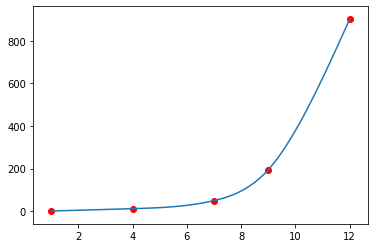

In [35]:
x_plot = np.linspace(x[0], x[-1], 100)
y_plot = []

for num in x_plot:
    y_calc = evaluate_spline(num)
    y_plot.append(y_calc)
    
plt.plot(x_plot, y_plot)
plt.scatter(x, y, color = 'red')
plt.show()